In [1]:
import pandas as pd
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='ISO-8859-1')
print(df.head())
print(df.info())

       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Benefit per order  Sales per customer   Delivery Status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   Late_delivery_risk  Category Id   Category Name Customer City  ...  \
0                   0           73  Sporting Goods        Caguas  ...   
1                   1           73  Sporting Goo

In [2]:

print(df.isnull().sum())
df.drop(columns=['Product Description'], inplace=True)
df['Customer Lname'] = df['Customer Lname'].fillna('Unknown')

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [3]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

In [4]:
df.drop_duplicates(inplace=True)

In [5]:
category_sales = df.groupby('Category Name')['Sales'].sum().reset_index()
category_sales = category_sales.sort_values(by='Sales', ascending=False).head(10)

/tmp/ipykernel_464/1256104035.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales, x='Sales', y='Category Name', palette='viridis')


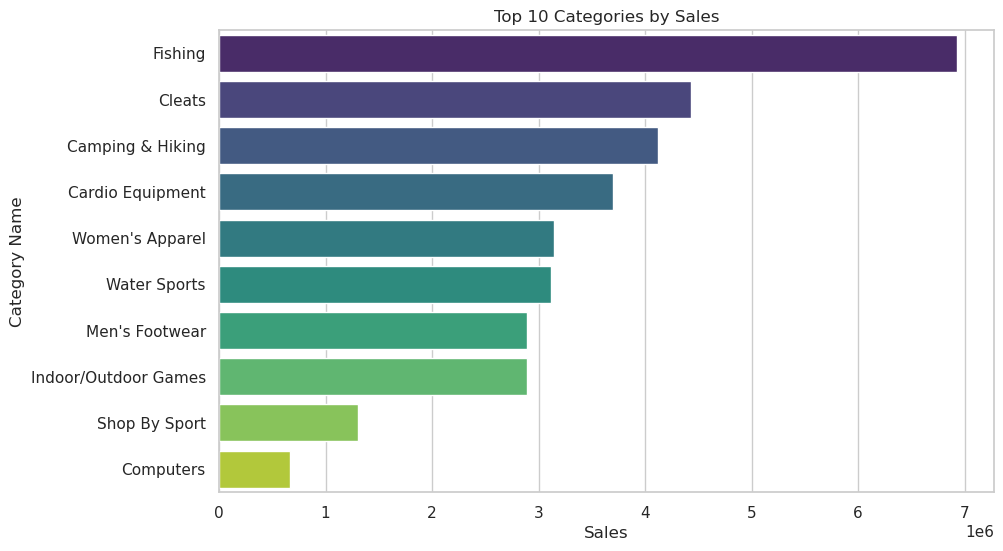

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
sns.barplot(data=category_sales, x='Sales', y='Category Name', palette='viridis')
plt.title('Top 10 Categories by Sales')
plt.show()

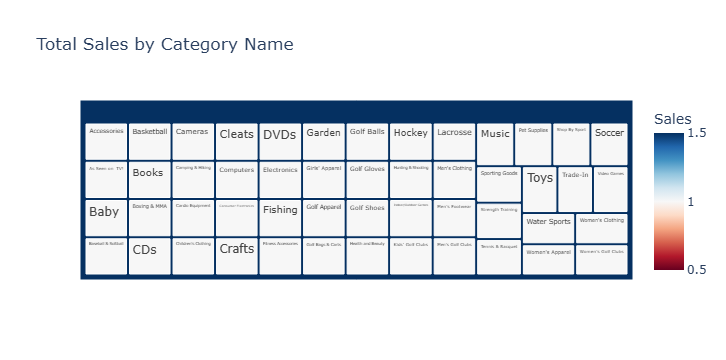

In [10]:
df_agg = df.groupby('Category Name')['Sales'].sum().reset_index()
fig = px.treemap(df_agg, 
                 path=['Category Name'], 
                 values='Sales',
                 color='Sales',
                 color_continuous_scale='RdBu',
                 title='Total Sales by Category Name')
fig.show()

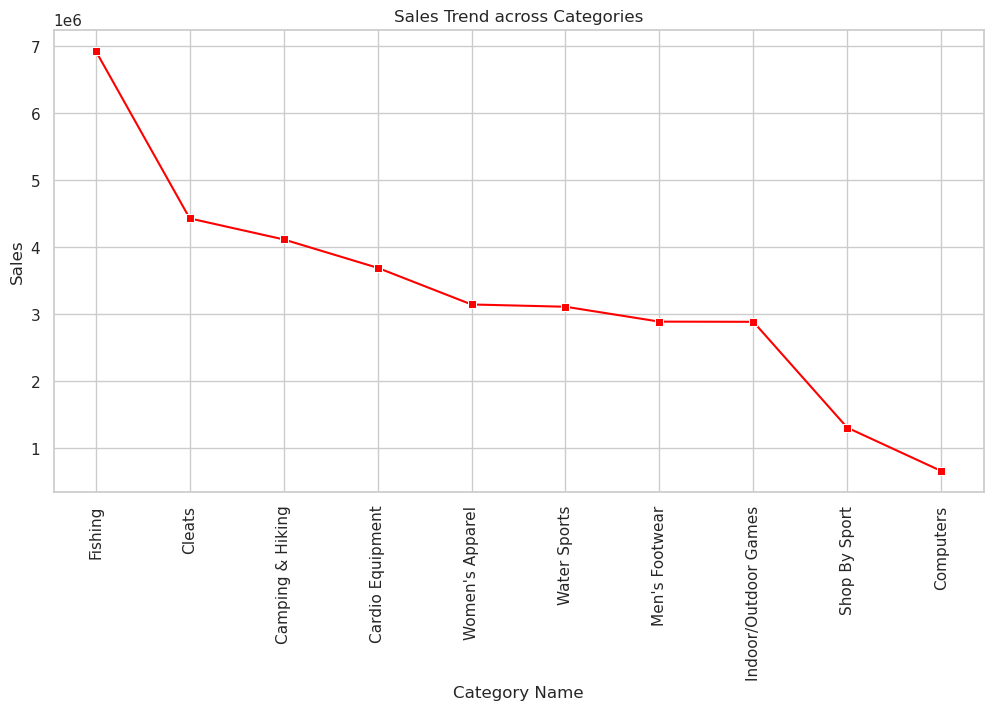

In [11]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=category_sales, x='Category Name', y='Sales', marker='s', color='red')

plt.xticks(rotation=90)
plt.title('Sales Trend across Categories')
plt.show()

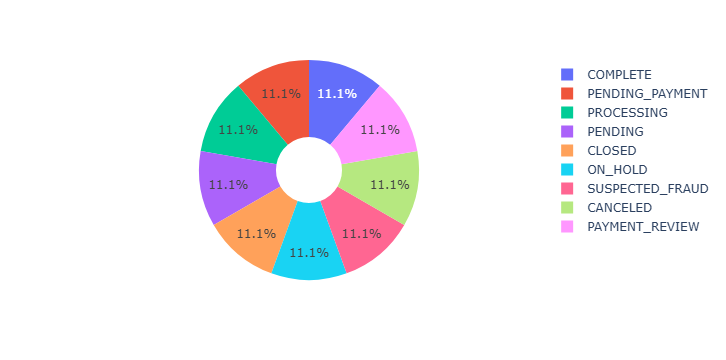

In [13]:
status_df = df['Order Status'].value_counts().reset_index()
status_df.columns = ['Order Status', 'Order Count']
fig = px.pie(status_df, 
             values='Order Count', 
             names='Order Status',
             hole=0.3) 

fig.show()

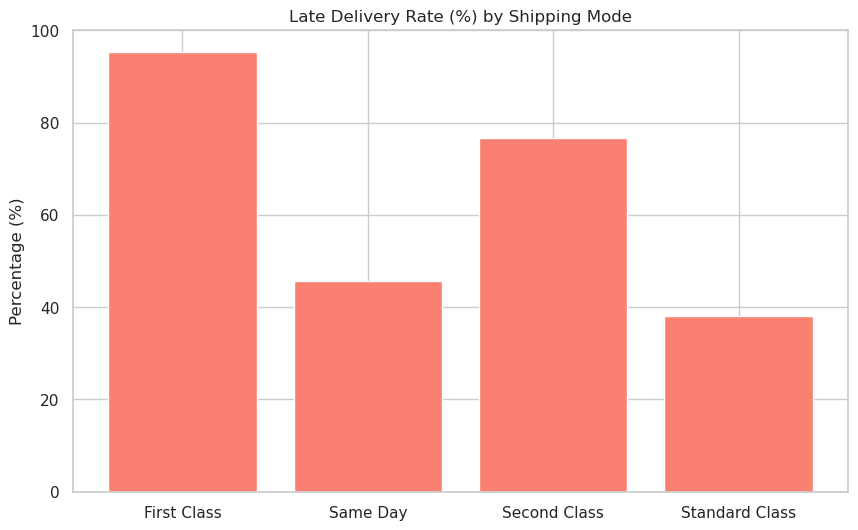

In [14]:

late_rate = df.groupby('Shipping Mode')['Late_delivery_risk'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.bar(late_rate['Shipping Mode'], late_rate['Late_delivery_risk'] * 100, color='salmon')

plt.title('Late Delivery Rate (%) by Shipping Mode')
plt.ylabel('Percentage (%)')
plt.show()

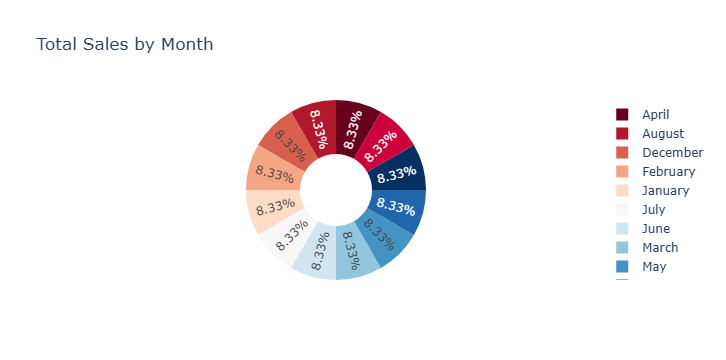

In [15]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['Month'] = df['order date (DateOrders)'].dt.month_name()
month_sales = df.groupby('Month')['Sales'].sum().reset_index()
fig = px.pie(month_sales, 
             values='Sales', 
             names='Month', 
             hole=0.4, 
             title='Total Sales by Month',
             color_discrete_sequence=px.colors.sequential.RdBu)

fig.show()

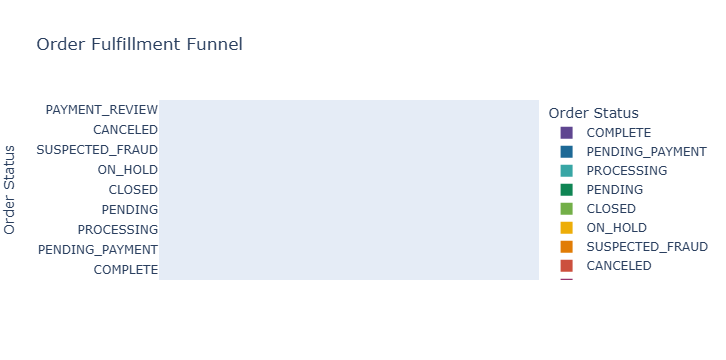

In [16]:

funnel_data = df.groupby('Order Status')['Order Id'].nunique().reset_index()
funnel_data.columns = ['Order Status', 'Order Count']
funnel_data = funnel_data.sort_values(by='Order Count', ascending=False)
fig = px.funnel(funnel_data, 
                x='Order Count', 
                y='Order Status', 
                title='Order Fulfillment Funnel',
                color='Order Status',
                color_discrete_sequence=px.colors.qualitative.Prism)

fig.show()

In [17]:
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='ISO-8859-1')
df['Delay'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']
matrix = df.pivot_table(index='Market', 
                        columns='Shipping Mode', 
                        values='Delay', 
                        aggfunc='mean')

print(matrix)

Shipping Mode  First Class  Same Day  Second Class  Standard Class
Market                                                            
Africa                 1.0  0.474551      1.982440        0.024096
Europe                 1.0  0.486046      2.003448       -0.010188
LATAM                  1.0  0.510943      1.981890       -0.005045
Pacific Asia           1.0  0.448338      1.998404       -0.003579
USCA                   1.0  0.451185      1.975318       -0.004131


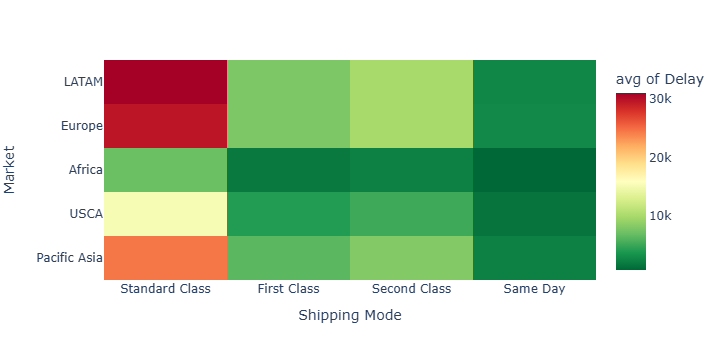

In [18]:
import plotly.express as px
fig = px.density_heatmap(df, x="Shipping Mode", y="Market", z="Delay", 
                         histfunc="avg", color_continuous_scale='RdYlGn_r')
fig.show()